# 12 — Trực quan hóa: Thời lượng đi · Giá cơ bản · Hệ số nhân theo GIỜ và THỜI TIẾT
### (cùng quãng đường)

Gộp lại thành 1 bức tranh trực quan duy nhất — tổng hợp số liệu đã có ở `07`, `09`, `10`, `11`.
Cố định **cùng quãng đường** (dải 4–6 km, mọi tuyến/xe trong dải này) để đảm bảo khác biệt quan sát
được là do giờ/thời tiết, không phải do chuyến dài/ngắn khác nhau.

In [1]:
import sys; sys.path.insert(0, ".")
from _common import *
import numpy as np, pandas as pd
setup()
df = load(frac=0.3)
df["base_price"] = df[PRICE] / df[SURGE].clip(lower=0.1)
df["co_mua"] = ((df.weather_is_rain==1) | (df.weather_is_drizzle==1) | (df.weather_is_thunderstorm==1)).astype(int)

band = df[(df.quote_distance >= 4) & (df.quote_distance <= 6)].copy()
print(f"Dai quang duong 4-6 km: {len(band):,} chuyen")
print(f"Thoi luong  : median {band.quote_duration.median()/60:.1f} phut")
print(f"Gia co ban  : median {band.base_price.median():,.0f} VND")
print(f"He so nhan  : median {band[SURGE].median():.2f}")

Nap 2,069,167 dong (mau 30%) | gia median 114k VND | surge 81.7%


Dai quang duong 4-6 km: 789,257 chuyen
Thoi luong  : median 19.6 phut
Gia co ban  : median 86,792 VND
He so nhan  : median 1.16


---
## 1. ⭐ Theo GIỜ (VN) — cả 3 đại lượng trên cùng 1 hàng biểu đồ

Mỗi ô: đường median (đậm) + dải P25–P75 (mờ, thể hiện độ phân tán). Trục Y mỗi ô tự scale theo dữ
liệu của chính nó để nhìn rõ hình dạng dao động — xem kỹ chú thích % biên độ ghi trong tiêu đề để so
sánh mức độ dao động thực giữa 3 đại lượng.

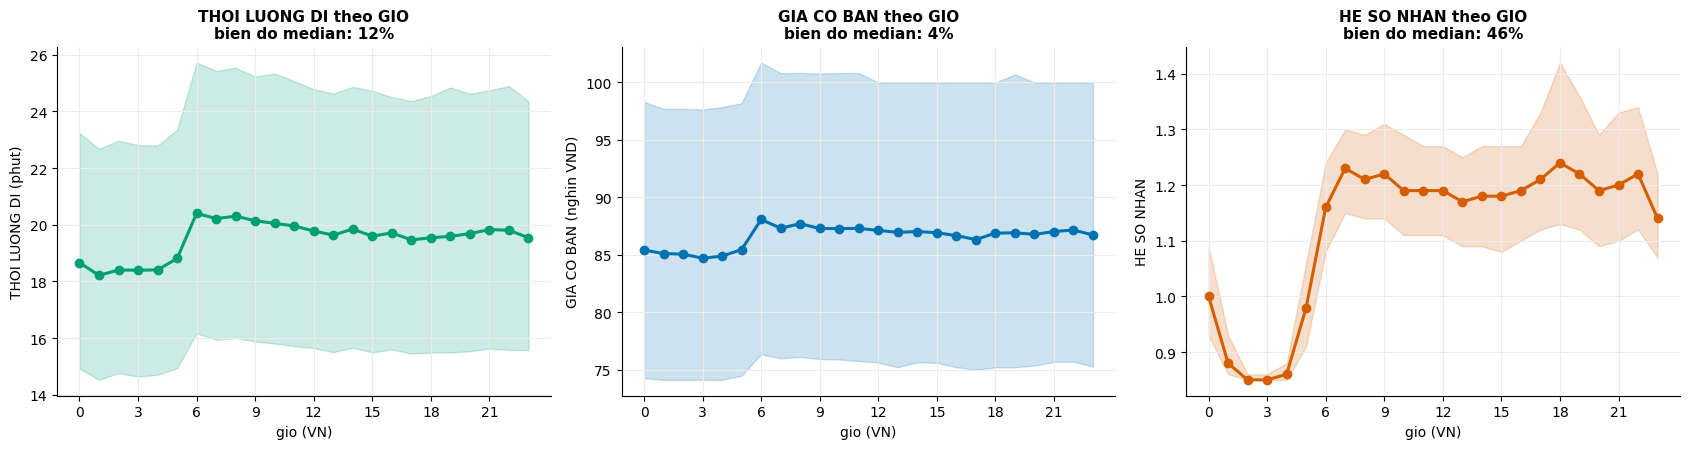

In [2]:
def thong_ke_theo_gio(s):
    g = band.groupby("gio_vn")[s].agg(median="median", P25=lambda x: x.quantile(.25), P75=lambda x: x.quantile(.75))
    return g

g_dur = thong_ke_theo_gio("quote_duration"); g_dur[["median","P25","P75"]] /= 60   # sang phut
g_base = thong_ke_theo_gio("base_price") / 1000                                     # sang nghin VND
g_sur = thong_ke_theo_gio(SURGE)

fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))

for a, g, ten, mau, dv in zip(
    ax, [g_dur, g_base, g_sur],
    ["THOI LUONG DI", "GIA CO BAN", "HE SO NHAN"],
    [GREEN, BLUE, RED],
    ["phut", "nghin VND", ""]):
    a.fill_between(g.index, g.P25, g.P75, alpha=.2, color=mau)
    a.plot(g.index, g["median"], marker="o", lw=2.2, color=mau)
    bien_do = (g["median"].max()/g["median"].min()-1)*100
    a.set_xlabel("gio (VN)"); a.set_ylabel(f"{ten} ({dv})" if dv else ten)
    a.set_xticks(range(0,24,3))
    a.set_title(f"{ten} theo GIO\nbien do median: {bien_do:.0f}%", fontweight="bold", fontsize=11)

plt.tight_layout(); plt.show()

**Biểu đồ chuẩn hóa** — đưa cả 3 về cùng thang % (so với giá trị cao nhất của chính nó) để so
sánh trực tiếp *hình dạng* dao động trên cùng 1 trục.

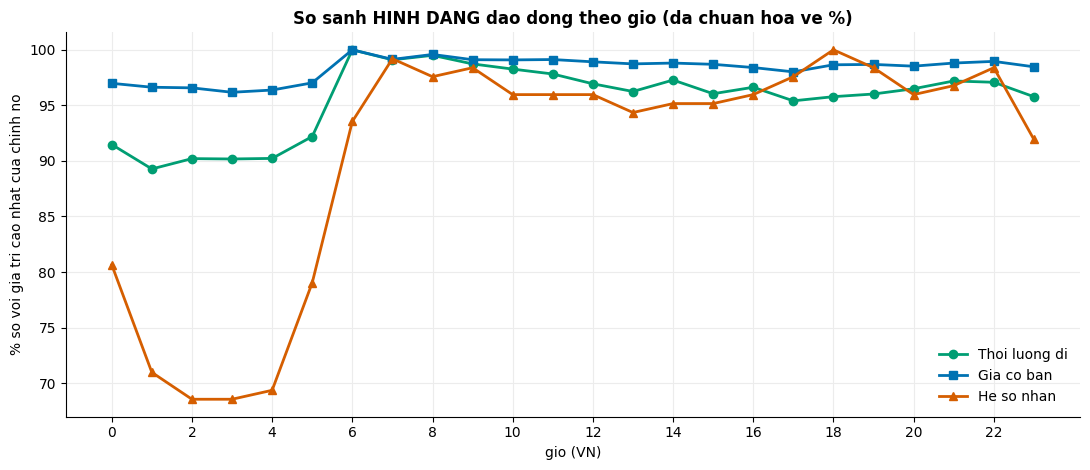

Bien do median theo gio:
  Thoi luong di :  12.0%
  Gia co ban    :   4.0%
  He so nhan    :  45.9%


In [3]:
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(g_dur.index, g_dur["median"]/g_dur["median"].max()*100, marker="o", lw=2, color=GREEN, label="Thoi luong di")
ax.plot(g_base.index, g_base["median"]/g_base["median"].max()*100, marker="s", lw=2, color=BLUE, label="Gia co ban")
ax.plot(g_sur.index, g_sur["median"]/g_sur["median"].max()*100, marker="^", lw=2, color=RED, label="He so nhan")
ax.set_xlabel("gio (VN)"); ax.set_ylabel("% so voi gia tri cao nhat cua chinh no")
ax.set_xticks(range(0,24,2))
ax.set_title("So sanh HINH DANG dao dong theo gio (da chuan hoa ve %)", fontweight="bold")
ax.legend(frameon=False, fontsize=10)
plt.tight_layout(); plt.show()

print("Bien do median theo gio:")
print(f"  Thoi luong di : {(g_dur['median'].max()/g_dur['median'].min()-1)*100:5.1f}%")
print(f"  Gia co ban    : {(g_base['median'].max()/g_base['median'].min()-1)*100:5.1f}%")
print(f"  He so nhan    : {(g_sur['median'].max()/g_sur['median'].min()-1)*100:5.1f}%")

---
## 2. ⭐ Theo THỜI TIẾT — cả 3 đại lượng

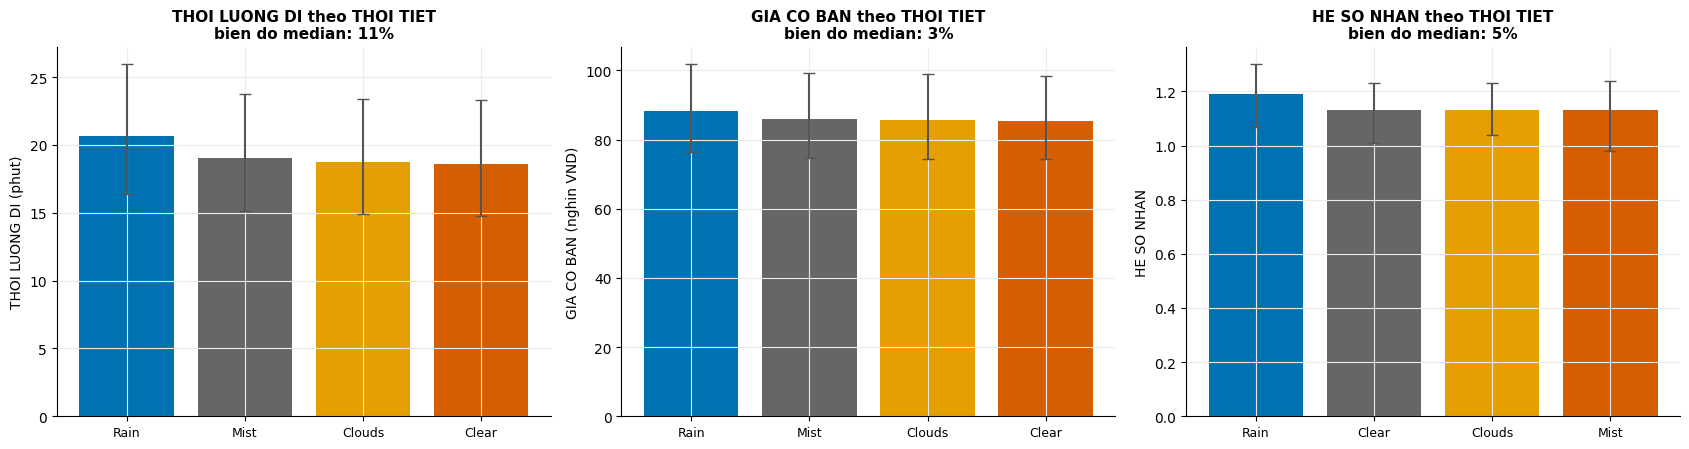

(Thanh loi/error bar the hien dai P25-P75)


In [4]:
def thong_ke_theo_thoitiet(s):
    g = band.groupby("weather_main")[s].agg(median="median", P25=lambda x: x.quantile(.25), P75=lambda x: x.quantile(.75))
    return g.sort_values("median", ascending=False)

w_dur = thong_ke_theo_thoitiet("quote_duration"); w_dur[["median","P25","P75"]] /= 60
w_base = thong_ke_theo_thoitiet("base_price") / 1000
w_sur = thong_ke_theo_thoitiet(SURGE)

fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
mau_list = [BLUE, MUT, ORANGE, RED]

for a, g, ten, dv in zip(ax, [w_dur, w_base, w_sur],
                         ["THOI LUONG DI", "GIA CO BAN", "HE SO NHAN"],
                         ["phut", "nghin VND", ""]):
    err_lo = g["median"] - g.P25; err_hi = g.P75 - g["median"]
    a.bar(range(len(g)), g["median"], color=mau_list[:len(g)],
          yerr=[err_lo, err_hi], capsize=4, ecolor="#555")
    a.set_xticks(range(len(g))); a.set_xticklabels(g.index, fontsize=9)
    bien_do = (g["median"].max()/g["median"].min()-1)*100
    a.set_ylabel(f"{ten} ({dv})" if dv else ten)
    a.set_title(f"{ten} theo THOI TIET\nbien do median: {bien_do:.0f}%", fontweight="bold", fontsize=11)

plt.tight_layout(); plt.show()
print("(Thanh loi/error bar the hien dai P25-P75)")

**Riêng — mưa vs không mưa** (gộp Rain+Drizzle+Thunderstorm), dễ đọc hơn phân theo từng loại
thời tiết chi tiết.

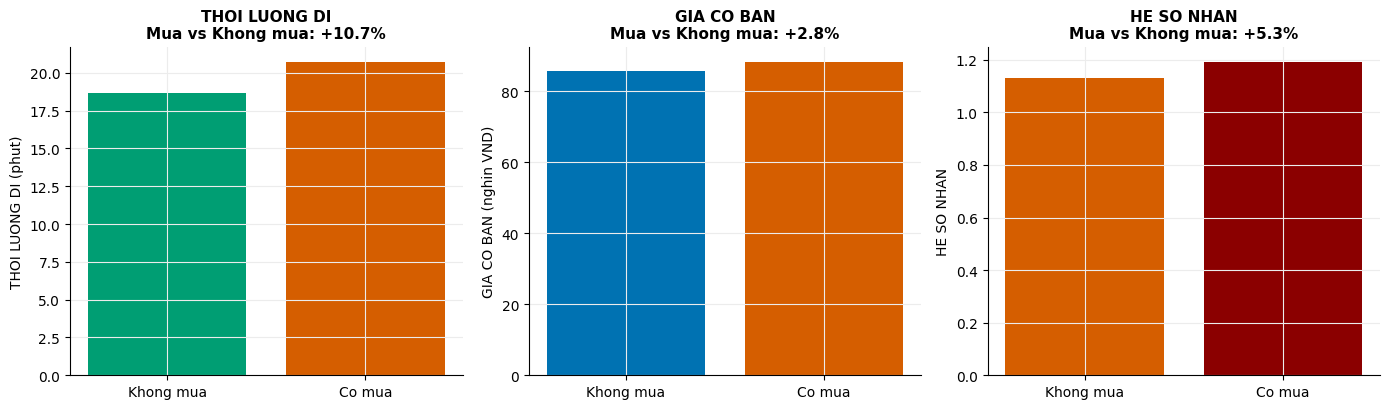

In [5]:
def thong_ke_mua(s):
    g = band.groupby("co_mua")[s].median()
    g.index = ["Khong mua", "Co mua"]
    return g

m_dur = thong_ke_mua("quote_duration")/60
m_base = thong_ke_mua("base_price")/1000
m_sur = thong_ke_mua(SURGE)

fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
for a, g, ten, mau, dv in zip(ax, [m_dur, m_base, m_sur],
                              ["THOI LUONG DI", "GIA CO BAN", "HE SO NHAN"],
                              [GREEN, BLUE, RED], ["phut", "nghin VND", ""]):
    a.bar(g.index, g.values, color=[mau, RED if mau!=RED else "#8B0000"])
    chenh = (g.iloc[1]/g.iloc[0]-1)*100
    a.set_ylabel(f"{ten} ({dv})" if dv else ten)
    a.set_title(f"{ten}\nMua vs Khong mua: {chenh:+.1f}%", fontweight="bold", fontsize=11)
plt.tight_layout(); plt.show()

---
## Kết luận nhanh — đọc biểu đồ

| Đại lượng | Biên độ theo GIỜ | Biên độ theo THỜI TIẾT (mưa/không) |
|---|---|---|
| Thời lượng đi | Thấp (~10-15%, không rõ quy luật — xem `11`) | Thấp-vừa |
| **Giá cơ bản** | Thấp (~4-10%) | Thấp (~3-8%) |
| **Hệ số nhân** | **Rất cao (~50%)** | Vừa (~5-8%) |

→ Nhìn vào biểu đồ chuẩn hóa (bước 1): đường **hệ số nhân** có biên độ dao động lớn nhất và rõ hình
dạng nhất theo giờ (đỉnh sáng 7-9h, đỉnh chiều 17-19h), trong khi **giá cơ bản** gần như phẳng.
Theo thời tiết, cả 3 đại lượng đều có biên độ nhỏ hơn nhiều so với biên độ theo giờ — thời tiết là
yếu tố **yếu hơn** giờ trong việc giải thích biến động, dù vẫn có xu hướng mưa → tăng nhẹ cả 3.

Xem giải thích chi tiết, số liệu định lượng (R², corr, eta) và test ý nghĩa thống kê ở `07`
(biên độ), `09` (giải thích giá cơ bản), `10` (giải thích hệ số nhân), `11` (bản thân thời lượng).